# 02. Deterministic Physics Baseline

Goal:
- Use the lightweight outputs from `01_inspect_dataset.ipynb`.
- Estimate local ball velocity right before occlusion.
- Simulate Pong trajectory from occlusion to final time.
- Compare deterministic physics prediction with:
  1. true final ball position
  2. animal paddle response

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in [PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MANIFEST_CSV = INTERIM_DIR / "mahler_condition_manifest.csv"
MANIFEST_PARQUET = INTERIM_DIR / "mahler_condition_manifest.parquet"
ARRAYS_NPZ = INTERIM_DIR / "mahler_occ_trajectory_arrays.npz"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MANIFEST_CSV exists:", MANIFEST_CSV.exists())
print("MANIFEST_PARQUET exists:", MANIFEST_PARQUET.exists())
print("ARRAYS_NPZ exists:", ARRAYS_NPZ.exists())

PROJECT_ROOT: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents
MANIFEST_CSV exists: True
MANIFEST_PARQUET exists: False
ARRAYS_NPZ exists: True


In [2]:
if MANIFEST_PARQUET.exists():
    manifest = pd.read_parquet(MANIFEST_PARQUET)
else:
    manifest = pd.read_csv(MANIFEST_CSV)

arrays = np.load(ARRAYS_NPZ)

ball_x = arrays["ball_pos_x"]
ball_y = arrays["ball_pos_y"]
paddle_y = arrays["paddle_pos_y"]

print("manifest shape:", manifest.shape)
print("ball_x shape:", ball_x.shape)
print("ball_y shape:", ball_y.shape)
print("paddle_y shape:", paddle_y.shape)

display(manifest.head())

manifest shape: (79, 29)
ball_x shape: (79, 100)
ball_y shape: (79, 100)
paddle_y shape: (79, 100)


,condition_i,meta_index,x0_mworks,y0_mworks,yf_mworks,x0_raw,y0_raw,yf_raw,heading0,speed0,n_bounce,vx_param,vy_param,vx_trace_step,vy_trace_step,first_valid_idx,last_valid_idx,occ_idx,final_idx,horizon_steps_occ_to_final,ball_y_at_occ,ball_y_at_final,paddle_y_at_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
0,0,29337.0,-7.0,-8.8,-0.271381,4.80,1.92,15.565790,0.463859,0.50,1.0,0.447166,0.223701,0.335375,0.167776,6,98,41,56,15,-2.787992,-0.271351,-0.688933,142,0.654930,0.190141,0.154930,1.016034,-0.405027
1,1,55062.0,-6.2,-4.4,-4.425255,6.08,8.96,8.919592,-0.565065,0.50,0.0,0.422277,-0.267735,0.316708,-0.200801,6,98,41,56,15,-8.066386,-5.085590,-3.723874,124,0.612903,0.370968,0.016129,1.599905,0.487836
2,2,58244.0,-6.2,4.2,-6.174745,6.08,22.72,6.120408,-0.565065,0.50,1.0,0.422277,-0.267735,0.316708,-0.200802,6,98,41,56,15,-2.995164,-6.007161,-5.745208,123,0.699187,0.260163,0.040650,1.400058,0.675314
3,3,59920.0,-6.2,8.6,-9.105659,6.08,29.76,1.430946,-0.851814,0.75,1.0,0.493964,-0.564357,0.370473,-0.423268,6,98,36,49,13,-4.450462,-9.766393,-7.246475,117,0.410256,0.529915,0.059829,2.133472,2.086257
4,4,68220.0,-5.8,-6.4,5.694221,6.72,5.76,25.110754,0.649403,0.50,0.0,0.398222,0.302356,0.298667,0.226767,6,98,42,58,16,1.952503,5.580769,5.144827,128,0.742188,0.210938,0.046875,1.293350,-0.610159


In [3]:
summary = pd.DataFrame({
    "variable": ["ball_x", "ball_y", "paddle_y"],
    "min": [np.nanmin(ball_x), np.nanmin(ball_y), np.nanmin(paddle_y)],
    "max": [np.nanmax(ball_x), np.nanmax(ball_y), np.nanmax(paddle_y)],
    "mean": [np.nanmean(ball_x), np.nanmean(ball_y), np.nanmean(paddle_y)],
    "std": [np.nanstd(ball_x), np.nanstd(ball_y), np.nanstd(paddle_y)],
})

display(summary)

# Check x position at occlusion and final.
x_occ = []
x_final = []
y_occ = []
y_final = []

for _, row in manifest.iterrows():
    ci = int(row["condition_i"])
    oi = int(row["occ_idx"])
    fi = int(row["final_idx"])
    
    x_occ.append(ball_x[ci, oi])
    x_final.append(ball_x[ci, fi])
    y_occ.append(ball_y[ci, oi])
    y_final.append(ball_y[ci, fi])

event_summary = pd.DataFrame({
    "x_occ": x_occ,
    "x_final": x_final,
    "y_occ": y_occ,
    "y_final": y_final,
})

display(event_summary.describe())

,variable,min,max,mean,std
0,ball_x,-6.720460,10.260570,3.682166,3.539638
1,ball_y,-9.804470,9.811464,-0.649075,4.123051
2,paddle_y,-7.331177,6.934683,-0.288200,2.302625


,x_occ,x_final,y_occ,y_final
count,79.000000,79.000000,79.000000,79.000000
mean,5.101470,10.021295,-0.605614,-0.505324
std,0.104269,0.112224,5.303557,5.400964
min,4.905131,9.764482,-9.792950,-9.766393
25%,5.017118,9.944389,-4.468215,-5.397608
50%,5.101676,10.018802,-1.426503,-0.951839
75%,5.193101,10.100165,3.135593,4.697695
max,5.347892,10.238052,9.631794,8.901912


In [4]:
def estimate_local_velocity(x_trace, y_trace, center_idx, window=6):
    """
    Estimate local velocity right before center_idx.
    
    Unit:
        position per time-bin.
    
    Because this dataset is sampled every 50 ms,
    this velocity is not per second. It is per 50-ms step.
    That is fine because our simulator also updates one bin at a time.
    """
    x_trace = np.asarray(x_trace)
    y_trace = np.asarray(y_trace)
    
    center_idx = int(center_idx)
    lo = max(0, center_idx - window)
    hi = center_idx + 1
    
    idx = np.arange(lo, hi)
    valid = np.isfinite(x_trace[idx]) & np.isfinite(y_trace[idx])
    idx = idx[valid]
    
    if len(idx) < 2:
        return np.nan, np.nan
    
    dx = np.diff(x_trace[idx])
    dy = np.diff(y_trace[idx])
    
    vx = np.nanmedian(dx)
    vy = np.nanmedian(dy)
    
    return vx, vy

In [5]:
def reflect_y(y, vy, y_min=-10.0, y_max=10.0):
    """
    Reflect y position at horizontal walls.
    Handles overshoot after crossing the wall.
    """
    while y > y_max or y < y_min:
        if y > y_max:
            y = y_max - (y - y_max)
            vy = -vy
        elif y < y_min:
            y = y_min + (y_min - y)
            vy = -vy
    
    return y, vy


def simulate_pong_deterministic(
    x0,
    y0,
    vx,
    vy,
    n_steps,
    y_min=-10.0,
    y_max=10.0,
):
    """
    Deterministic Pong forward simulation.
    
    State:
        x_t, y_t, vx_t, vy_t
    
    Update:
        x_{t+1} = x_t + vx_t
        y_{t+1} = y_t + vy_t
        
    Bounce:
        If y crosses the upper/lower wall, reflect y and flip vy.
    """
    x = float(x0)
    y = float(y0)
    vx = float(vx)
    vy = float(vy)
    
    xs = [x]
    ys = [y]
    vxs = [vx]
    vys = [vy]
    
    for _ in range(int(n_steps)):
        x = x + vx
        y = y + vy
        
        y, vy = reflect_y(y, vy, y_min=y_min, y_max=y_max)
        
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)
    
    return {
        "x": np.array(xs),
        "y": np.array(ys),
        "vx": np.array(vxs),
        "vy": np.array(vys),
    }

In [6]:
Y_MIN = -10.0
Y_MAX = 10.0

condition_i = 0

row = manifest.loc[manifest["condition_i"] == condition_i].iloc[0]

ci = int(row["condition_i"])
oi = int(row["occ_idx"])
fi = int(row["final_idx"])
n_steps = fi - oi

x0 = ball_x[ci, oi]
y0 = ball_y[ci, oi]

vx_occ, vy_occ = estimate_local_velocity(
    ball_x[ci],
    ball_y[ci],
    center_idx=oi,
    window=6,
)

sim = simulate_pong_deterministic(
    x0=x0,
    y0=y0,
    vx=vx_occ,
    vy=vy_occ,
    n_steps=n_steps,
    y_min=Y_MIN,
    y_max=Y_MAX,
)

print("condition_i:", condition_i)
print("occ_idx:", oi)
print("final_idx:", fi)
print("n_steps:", n_steps)
print("x0, y0:", x0, y0)
print("vx_occ, vy_occ:", vx_occ, vy_occ)
print("true final y:", ball_y[ci, fi])
print("pred final y:", sim["y"][-1])
print("paddle final y:", paddle_y[ci, fi])

condition_i: 0
occ_idx: 41
final_idx: 56
n_steps: 15
x0, y0: 5.017654203985791 -2.7879922236017642
vx_occ, vy_occ: 0.3353746622948943 0.16777610676828614
true final y: -0.27135068572495796
pred final y: -0.2713506220774722
paddle final y: -0.6889326986050409


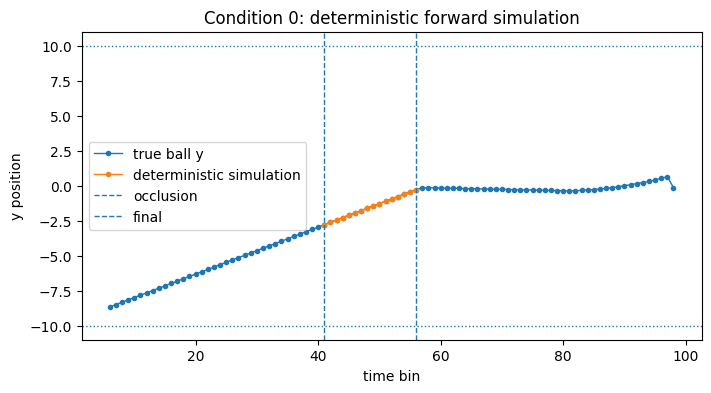

In [7]:
t_full = np.arange(ball_x.shape[1])
t_sim = np.arange(oi, fi + 1)

plt.figure(figsize=(8, 4))

plt.plot(
    t_full,
    ball_y[ci],
    marker="o",
    markersize=3,
    linewidth=1,
    label="true ball y"
)

plt.plot(
    t_sim,
    sim["y"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="deterministic simulation"
)

plt.axvline(oi, linestyle="--", linewidth=1, label="occlusion")
plt.axvline(fi, linestyle="--", linewidth=1, label="final")
plt.axhline(Y_MIN, linestyle=":", linewidth=1)
plt.axhline(Y_MAX, linestyle=":", linewidth=1)

plt.xlabel("time bin")
plt.ylabel("y position")
plt.title(f"Condition {condition_i}: deterministic forward simulation")
plt.legend()
plt.show()

In [8]:
rows = []

for _, row in manifest.iterrows():
    ci = int(row["condition_i"])
    oi = int(row["occ_idx"])
    fi = int(row["final_idx"])
    n_steps = fi - oi
    
    x0 = ball_x[ci, oi]
    y0 = ball_y[ci, oi]
    
    vx_occ, vy_occ = estimate_local_velocity(
        ball_x[ci],
        ball_y[ci],
        center_idx=oi,
        window=6,
    )
    
    sim = simulate_pong_deterministic(
        x0=x0,
        y0=y0,
        vx=vx_occ,
        vy=vy_occ,
        n_steps=n_steps,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )
    
    pred_y_final = sim["y"][-1]
    pred_x_final = sim["x"][-1]
    
    true_y_final = ball_y[ci, fi]
    true_x_final = ball_x[ci, fi]
    paddle_y_final = paddle_y[ci, fi]
    
    rows.append({
        "condition_i": ci,
        "meta_index": row["meta_index"],
        "occ_idx": oi,
        "final_idx": fi,
        "n_steps": n_steps,
        
        "x_occ": x0,
        "y_occ": y0,
        "vx_occ": vx_occ,
        "vy_occ": vy_occ,
        
        "pred_x_final": pred_x_final,
        "pred_y_final": pred_y_final,
        "true_x_final": true_x_final,
        "true_y_final": true_y_final,
        "paddle_y_final": paddle_y_final,
        
        "error_pred_vs_true": pred_y_final - true_y_final,
        "abs_error_pred_vs_true": abs(pred_y_final - true_y_final),
        
        "error_paddle_vs_true": paddle_y_final - true_y_final,
        "abs_error_paddle_vs_true": abs(paddle_y_final - true_y_final),
        
        "error_paddle_vs_pred": paddle_y_final - pred_y_final,
        "abs_error_paddle_vs_pred": abs(paddle_y_final - pred_y_final),
    })

det_results = pd.DataFrame(rows)

display(det_results.head())
display(det_results.describe())

,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,7.900000e+01,7.900000e+01,79.000000,79.000000,79.000000,79.000000
mean,39.000000,267992.518987,30.822785,49.329114,18.506329,5.101470,-0.605614,0.284385,0.012232,10.019778,-0.477061,10.021295,-0.505324,-0.628778,2.826369e-02,7.699444e-02,-0.123454,1.016004,-0.151717,1.017040
std,22.949219,126389.330509,6.726830,10.618950,5.843852,0.104269,5.303557,0.061713,0.225362,0.115932,5.493333,0.112224,5.400964,4.965906,2.472003e-01,2.364592e-01,1.453870,1.040997,1.451995,1.041139
min,0.000000,29337.000000,19.000000,34.000000,13.000000,4.905131,-9.792950,0.139663,-0.423268,9.764481,-9.952948,9.764482,-9.766393,-7.246475,-3.517926e-01,2.094769e-10,-5.582293,0.008800,-5.420789,0.008888
25%,19.500000,181150.500000,24.500000,41.500000,15.000000,5.017118,-4.468215,0.263192,-0.200802,9.932652,-5.397652,9.944389,-5.397608,-5.832213,-4.906526e-07,9.404788e-08,-0.714349,0.337020,-0.714349,0.313042
50%,39.000000,258471.000000,31.000000,48.000000,16.000000,5.101676,-1.426503,0.306145,0.108282,10.016636,-0.951839,10.018802,-0.951839,-1.275821,2.094769e-10,3.511917e-07,-0.143169,0.629003,-0.113175,0.630035
75%,58.500000,380457.000000,37.000000,55.000000,19.000000,5.193101,3.135593,0.329525,0.205177,10.108137,4.711319,10.100165,4.697695,4.725959,2.185665e-07,8.805072e-05,0.453318,1.389902,0.464832,1.334059
max,78.000000,469268.000000,42.000000,76.000000,35.000000,5.347892,9.631794,0.373387,0.429457,10.276568,9.259599,10.238052,8.901912,6.920324,1.555481e+00,1.555481e+00,4.722130,5.582293,4.549034,5.420789


In [9]:
def regression_metrics(y_pred, y_true):
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    y_pred = y_pred[valid]
    y_true = y_true[valid]
    
    error = y_pred - y_true
    
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    
    if len(y_pred) >= 2:
        corr = np.corrcoef(y_pred, y_true)[0, 1]
    else:
        corr = np.nan
    
    return {
        "n": len(y_pred),
        "mae": mae,
        "rmse": rmse,
        "corr": corr,
    }


metrics = pd.DataFrame([
    {
        "comparison": "deterministic_pred_vs_true_ball",
        **regression_metrics(
            det_results["pred_y_final"],
            det_results["true_y_final"],
        )
    },
    {
        "comparison": "paddle_response_vs_true_ball",
        **regression_metrics(
            det_results["paddle_y_final"],
            det_results["true_y_final"],
        )
    },
    {
        "comparison": "paddle_response_vs_deterministic_pred",
        **regression_metrics(
            det_results["paddle_y_final"],
            det_results["pred_y_final"],
        )
    },
])

display(metrics)

,comparison,n,mae,rmse,corr
0,deterministic_pred_vs_true_ball,79,0.076994,0.247252,0.999114
1,paddle_response_vs_true_ball,79,1.016004,1.449904,0.964124
2,paddle_response_vs_deterministic_pred,79,1.017040,1.450731,0.966456


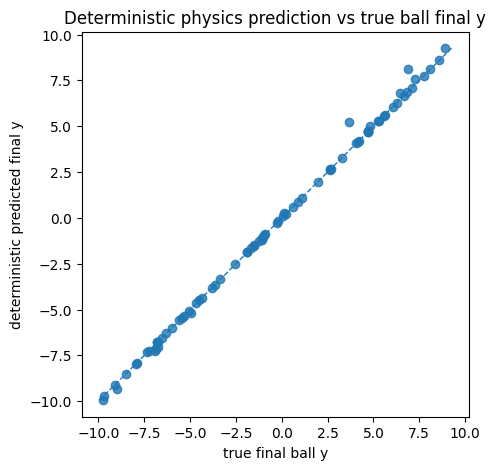

In [10]:
plt.figure(figsize=(5, 5))

plt.scatter(
    det_results["true_y_final"],
    det_results["pred_y_final"],
    alpha=0.8
)

lims = [
    min(det_results["true_y_final"].min(), det_results["pred_y_final"].min()),
    max(det_results["true_y_final"].max(), det_results["pred_y_final"].max()),
]

plt.plot(lims, lims, linestyle="--", linewidth=1)

plt.xlabel("true final ball y")
plt.ylabel("deterministic predicted final y")
plt.title("Deterministic physics prediction vs true ball final y")
plt.axis("equal")
plt.show()

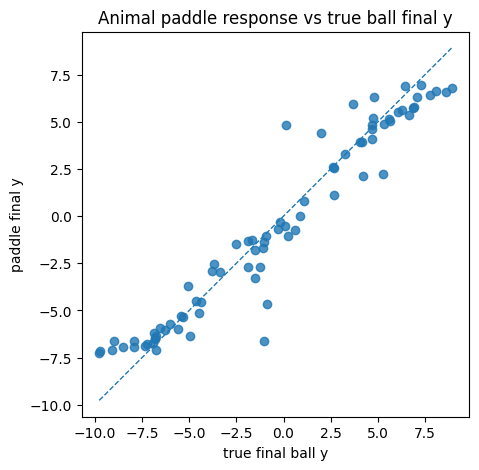

In [11]:
plt.figure(figsize=(5, 5))

plt.scatter(
    det_results["true_y_final"],
    det_results["paddle_y_final"],
    alpha=0.8
)

lims = [
    min(det_results["true_y_final"].min(), det_results["paddle_y_final"].min()),
    max(det_results["true_y_final"].max(), det_results["paddle_y_final"].max()),
]

plt.plot(lims, lims, linestyle="--", linewidth=1)

plt.xlabel("true final ball y")
plt.ylabel("paddle final y")
plt.title("Animal paddle response vs true ball final y")
plt.axis("equal")
plt.show()

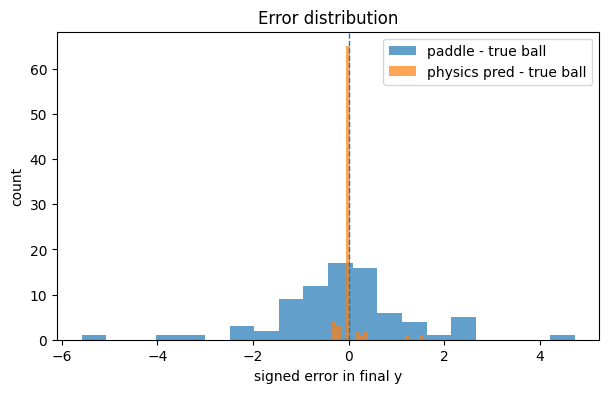

In [12]:
plt.figure(figsize=(7, 4))

plt.hist(
    det_results["error_paddle_vs_true"],
    bins=20,
    alpha=0.7,
    label="paddle - true ball"
)

plt.hist(
    det_results["error_pred_vs_true"],
    bins=20,
    alpha=0.7,
    label="physics pred - true ball"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("signed error in final y")
plt.ylabel("count")
plt.title("Error distribution")
plt.legend()
plt.show()

In [13]:
## Worst cases
worst_pred = det_results.sort_values("abs_error_pred_vs_true", ascending=False).head(10)
display(worst_pred)

worst_paddle = det_results.sort_values("abs_error_paddle_vs_true", ascending=False).head(10)
display(worst_paddle)

,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred
73,73,456038.0,24,44,20,5.168387,9.348128,0.242294,0.270429,10.014276,5.243288,10.088829,3.687806,5.920555,1.555481,1.555481,2.232749,2.232749,0.677267,0.677267
42,42,273073.0,25,40,15,5.113148,9.292690,0.339439,-0.078523,10.204737,8.114847,10.173513,6.911953,5.780513,1.202895,1.202895,-1.131440,1.131440,-2.334334,2.334334
34,34,242380.0,32,51,19,5.122581,5.707579,0.265444,0.264885,10.166025,9.259599,10.181100,8.901912,6.784557,0.357686,0.357686,-2.117356,2.117356,-2.475042,2.475042
9,9,93053.0,39,56,17,4.905131,-8.872451,0.298667,-0.226767,9.982468,-7.272516,9.993010,-6.920723,-6.741161,-0.351793,0.351793,0.179563,0.179563,0.531356,0.531356
20,20,182748.0,37,55,18,5.249536,8.431740,0.265444,0.264885,10.027536,6.800323,10.082815,6.458145,6.894891,0.342178,0.342178,0.436746,0.436746,0.094567,0.094567
52,52,340684.0,40,71,31,4.974160,-9.792950,0.160025,-0.097716,9.934929,-7.177869,9.956291,-6.842524,-6.190933,-0.335345,0.335345,0.651591,0.651591,0.986935,0.986935
41,41,270569.0,34,55,21,5.100684,-4.485969,0.232393,-0.294310,9.980937,-9.333518,9.991144,-9.006832,-6.639249,-0.326686,0.326686,2.367583,2.367583,2.694269,2.694269
48,48,325813.0,26,43,17,5.175178,-8.832883,0.286814,-0.241583,10.051023,-7.060200,10.056827,-6.746262,-7.106050,-0.313937,0.313937,-0.359788,0.359788,-0.045850,0.045850
27,27,204678.0,30,46,16,4.979690,9.118524,0.313276,0.206115,9.992103,7.583640,9.978536,7.286919,6.920324,0.296721,0.296721,-0.366594,0.366594,-0.663316,0.663316
33,33,241919.0,33,52,19,5.135267,-9.617576,0.256359,-0.273688,10.006090,-5.182356,10.081258,-4.945274,-6.363362,-0.237082,0.237082,-1.418088,1.418088,-1.181006,1.181006


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred
51,51,332165.0,40,69,29,5.069255,-9.070737,0.168483,-0.335020,9.955258,-1.213678,10.001997,-1.052173,-6.634466,-1.615043e-01,1.615043e-01,-5.582293,5.582293,-5.420789,5.420789
75,75,463174.0,36,71,35,5.106738,7.531867,0.139663,0.348022,9.994926,0.287361,10.017883,0.114265,4.836395,1.730961e-01,1.730961e-01,4.722130,4.722130,4.549034,4.549034
38,38,251629.0,35,56,21,5.168139,-7.020894,0.235995,0.291430,10.124037,-0.900872,10.124037,-0.900870,-4.666365,-1.971666e-06,1.971666e-06,-3.765496,3.765496,-3.765494,3.765494
37,37,248856.0,24,37,13,5.041825,-0.311868,0.363281,0.429457,9.764481,5.271068,9.764482,5.271068,2.214171,2.192683e-07,2.192683e-07,-3.056897,3.056897,-3.056897,3.056897
14,14,126479.0,34,50,16,4.922007,-6.678587,0.323300,-0.190005,10.094811,-9.718668,10.094811,-9.718668,-7.153478,4.728366e-07,4.728366e-07,2.565190,2.565190,2.565190,2.565190
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473
36,36,245662.0,34,54,20,5.153399,7.555935,0.250924,-0.278679,10.171879,1.982349,10.171879,1.982349,4.412908,2.178647e-07,2.178647e-07,2.430559,2.430559,2.430559,2.430559
41,41,270569.0,34,55,21,5.100684,-4.485969,0.232393,-0.294310,9.980937,-9.333518,9.991144,-9.006832,-6.639249,-3.266860e-01,3.266860e-01,2.367583,2.367583,2.694269,2.694269
73,73,456038.0,24,44,20,5.168387,9.348128,0.242294,0.270429,10.014276,5.243288,10.088829,3.687806,5.920555,1.555481e+00,1.555481e+00,2.232749,2.232749,0.677267,0.677267
34,34,242380.0,32,51,19,5.122581,5.707579,0.265444,0.264885,10.166025,9.259599,10.181100,8.901912,6.784557,3.576861e-01,3.576861e-01,-2.117356,2.117356,-2.475042,2.475042


In [14]:
det_path = PROCESSED_DIR / "deterministic_baseline_mahler.csv"
metrics_path = PROCESSED_DIR / "deterministic_baseline_metrics_mahler.csv"

det_results.to_csv(det_path, index=False)
metrics.to_csv(metrics_path, index=False)

print("Saved:", det_path)
print("Saved:", metrics_path)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\deterministic_baseline_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\deterministic_baseline_metrics_mahler.csv
